# Diabetes Prediction

Diabetes is a chronic illness that occurs when the body can't regulate blood sugar levels effectively. 

This notebook aims to built an ML model to predict whether patient has diabetes or not, based on the pimas Indians diabetes dataset

In [1]:
#libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc, classification_report

In [7]:
df = pd.read_csv('dataset/diabetes.csv')
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [8]:
#nulls
print("Missing values per column:\n", df.isnull().sum())

#dupes
print(f"\nDuplicate rows found: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)

#handle missing
cols_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_to_fix:
    df[col] = df[col].replace(0, np.nan)

#fill nans
df.fillna(df.median(), inplace=True)

Missing values per column:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Duplicate rows found: 0


C:\Users\anjan\AppData\Local\Temp\ipykernel_15600\3686876946.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=df, palette='viridis')


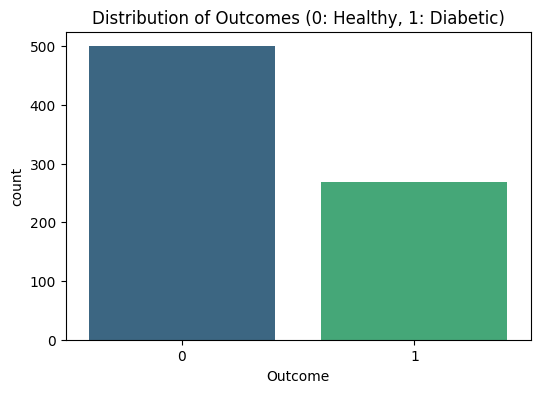

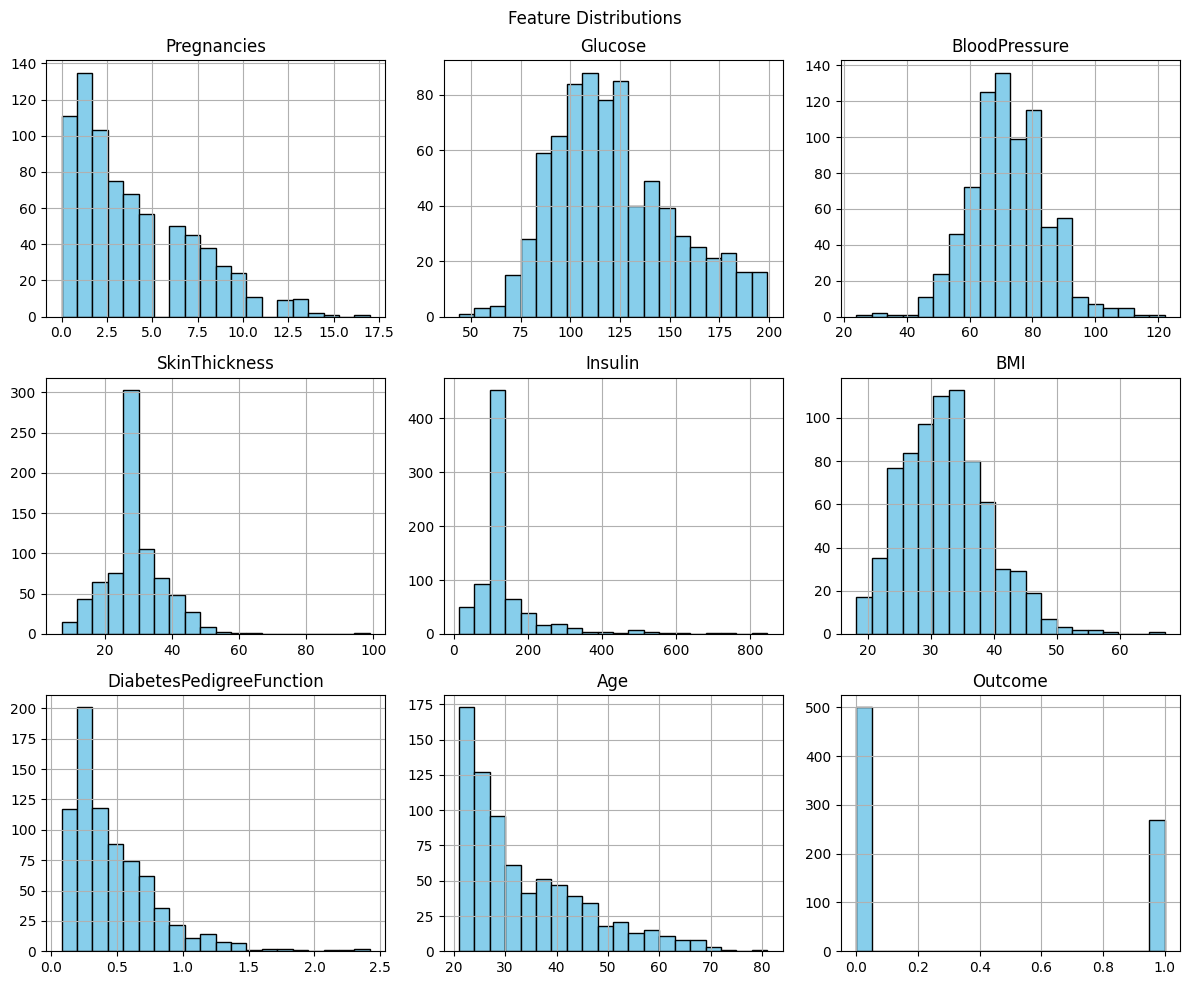

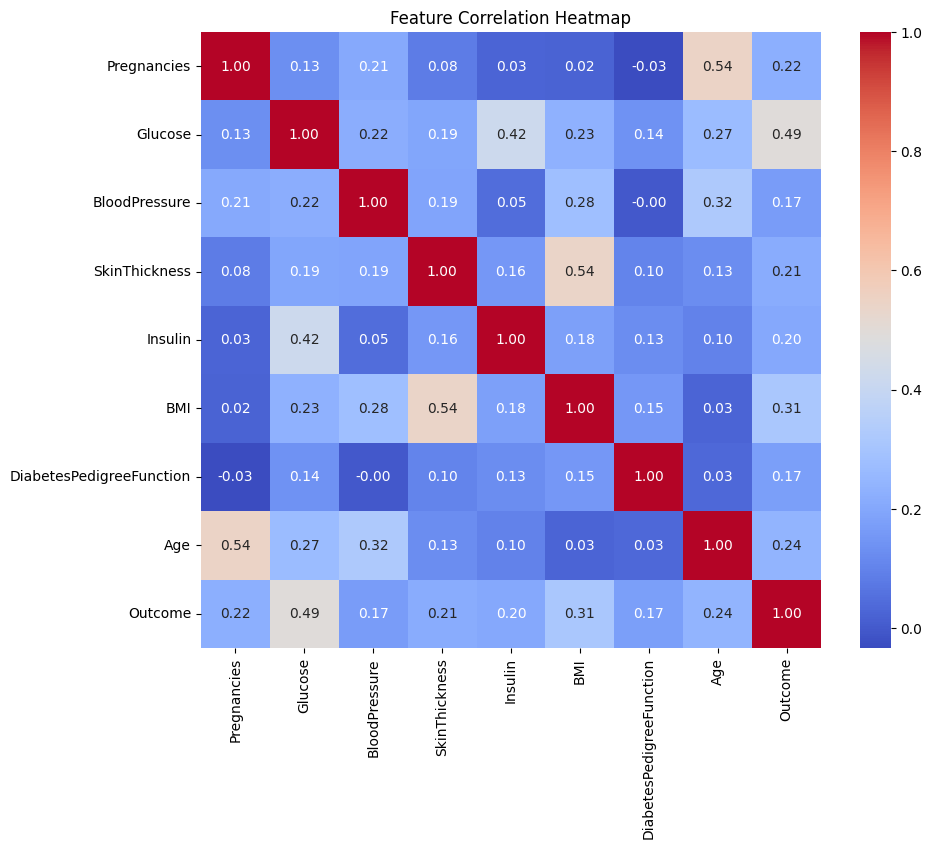

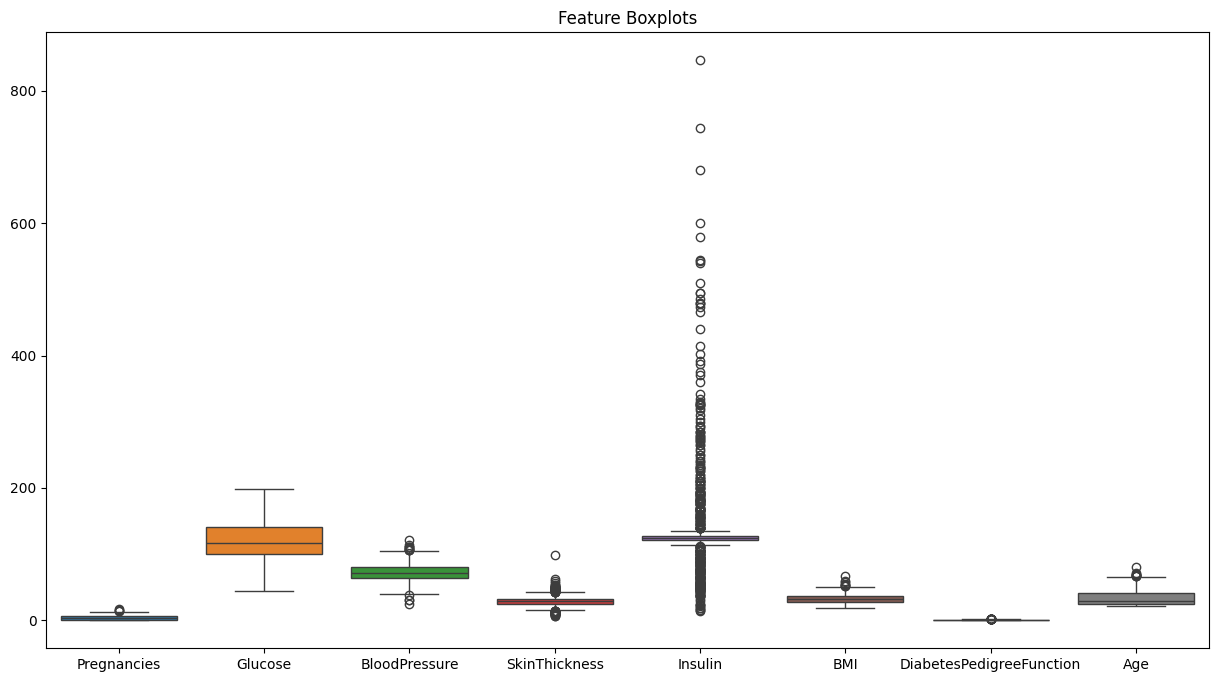

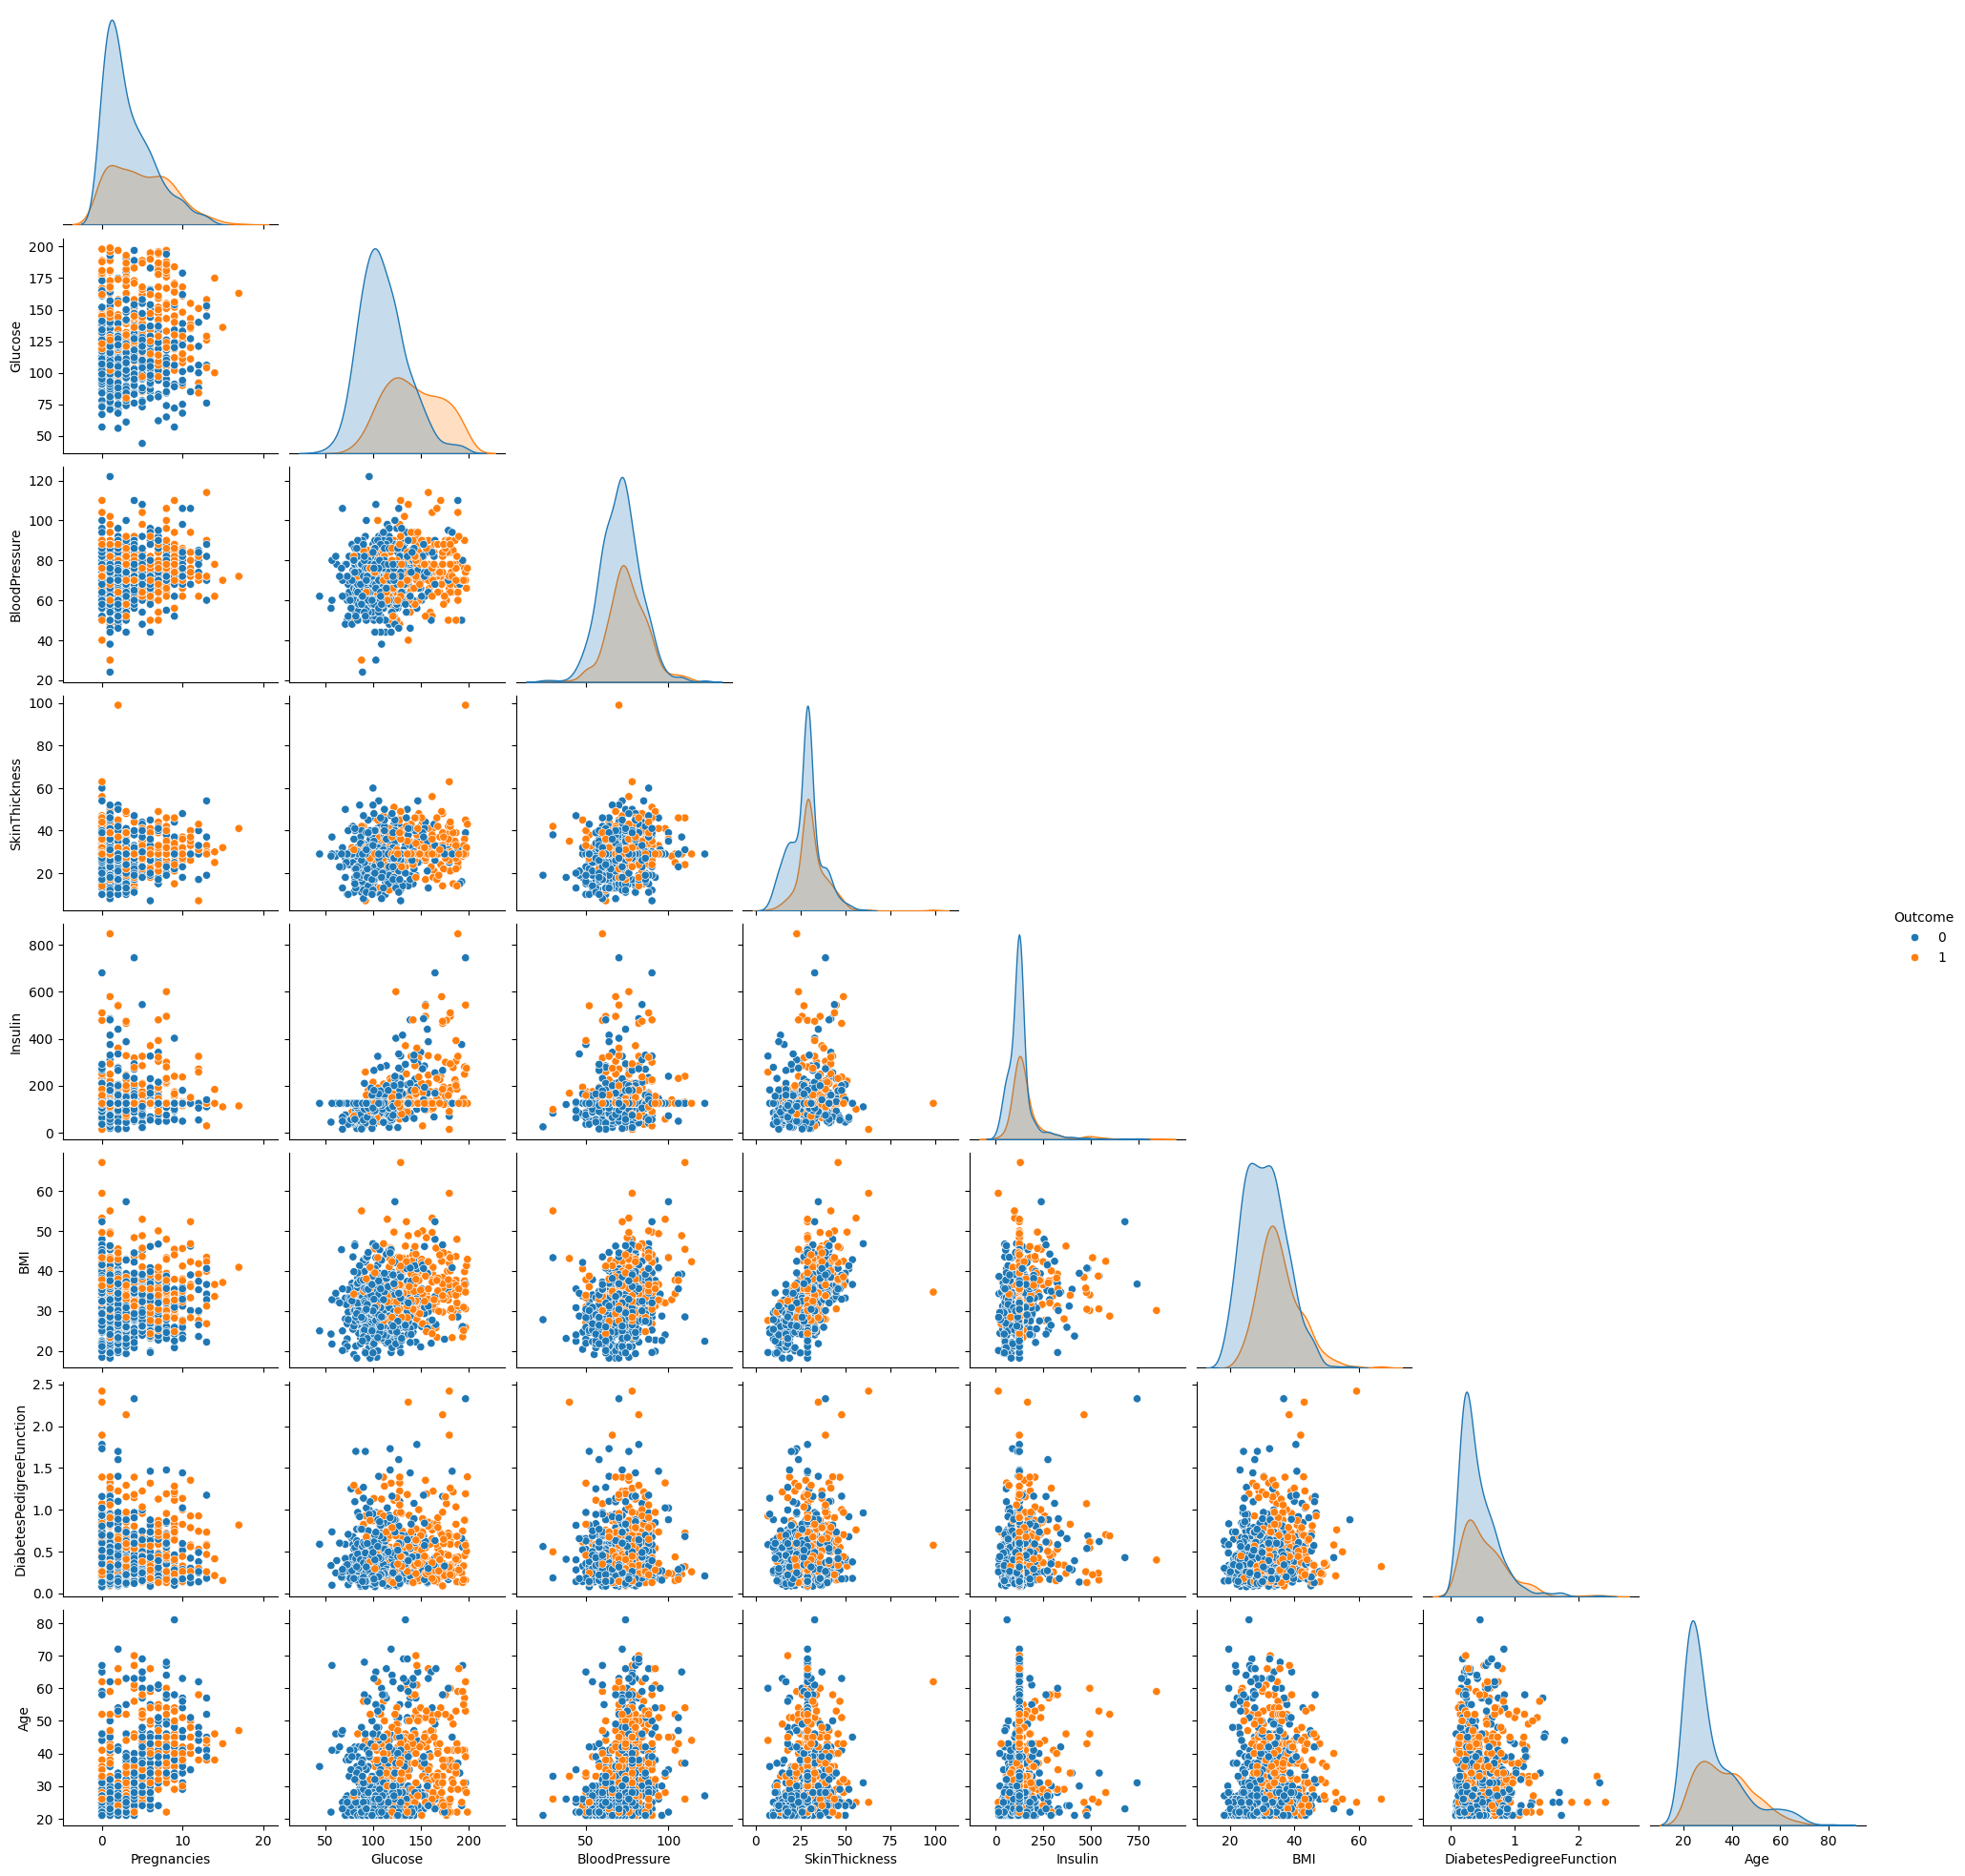

In [9]:
#class dist
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=df, palette='viridis')
plt.title('Distribution of Outcomes (0: Healthy, 1: Diabetic)')
plt.show()

#hist
df.hist(figsize=(12, 10), bins=20, color='skyblue', edgecolor='black')
plt.suptitle('Feature Distributions')
plt.tight_layout()
plt.show()

#corr heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

#boxplot to check for outliers
plt.figure(figsize=(15, 8))
sns.boxplot(data=df.drop('Outcome', axis=1))
plt.title('Feature Boxplots')
plt.show()

#pairplots
sns.pairplot(df, hue='Outcome', corner=True)
plt.show()

In [10]:
#scaling
X = df.drop('Outcome', axis=1)
y = df['Outcome']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

In [12]:
#train models
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "y_pred": y_pred,
        "y_prob": y_prob
    }

c:\Users\anjan\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [22:17:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model Performance Summary:
                     Accuracy Precision    Recall        F1
Logistic Regression  0.701299  0.586957       0.5      0.54
Random Forest        0.779221  0.727273  0.592593  0.653061
SVM                  0.733766  0.644444  0.537037  0.585859
KNN                  0.753247      0.66  0.611111  0.634615
XGBoost               0.75974  0.673469  0.611111  0.640777


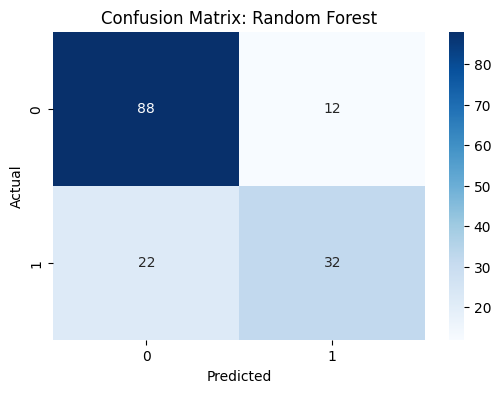

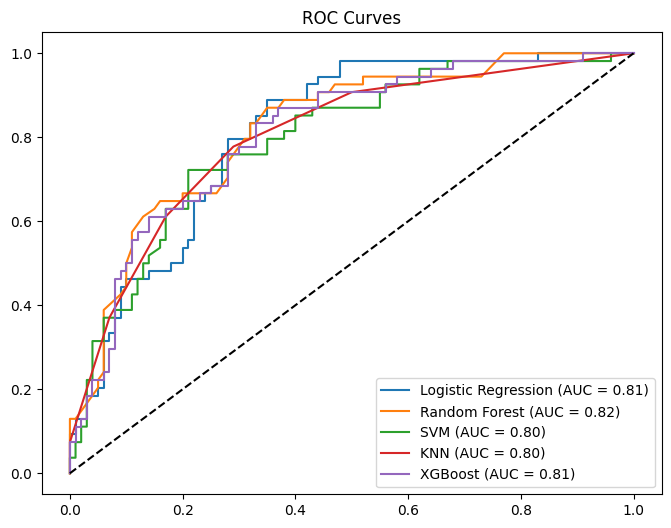

In [13]:
#eval
# Create summary table
summary_df = pd.DataFrame(results).T[['Accuracy', 'Precision', 'Recall', 'F1']]
print("Model Performance Summary:")
print(summary_df)

# Confusion Matrix for Best Model (Assuming Random Forest or Logistic)
best_model_name = summary_df['Accuracy'].idxmax()
cm = confusion_matrix(y_test, results[best_model_name]['y_pred'])

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix: {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve
plt.figure(figsize=(8, 6))
for name, data in results.items():
    fpr, tpr, _ = roc_curve(y_test, data['y_prob'])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curves')
plt.legend()
plt.show()

## Conclusion

Random Forest performed best with AUC 0.82, accuracy 0.77 

C:\Users\anjan\AppData\Local\Temp\ipykernel_15600\1036384376.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis')


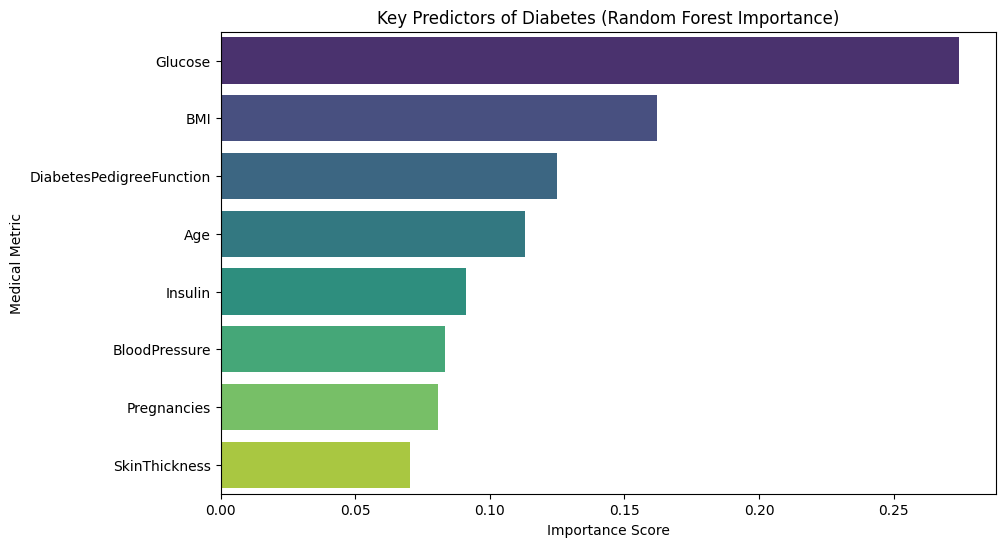

Feature Importance Rankings:
                    Feature  Importance
1                   Glucose    0.274086
5                       BMI    0.161903
6  DiabetesPedigreeFunction    0.125020
7                       Age    0.112985
4                   Insulin    0.091224
2             BloodPressure    0.083518
0               Pregnancies    0.080795
3             SkinThickness    0.070468


In [14]:
rf_model = models["Random Forest"]
feature_names = X.columns

#df for importances
fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis')

plt.title('Key Predictors of Diabetes (Random Forest Importance)')
plt.xlabel('Importance Score')
plt.ylabel('Medical Metric')
plt.show()

print("Feature Importance Rankings:")
print(fi_df)